In [8]:
!pip install confluent-kafka


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [23]:
from confluent_kafka import Consumer
import re
import pandas as pd
import os

os.makedirs("data/ratings", exist_ok=True)

# Kafka consumer config
conf = {
    'bootstrap.servers': 'localhost:9092',
    'group.id': 'ratings-consumer',
    'auto.offset.reset': 'latest'  # or 'earliest' to only get old messages
}

consumer = Consumer(conf)
consumer.subscribe(['movielog8'])

messages = []
max_messages = 100000   # adjust based on how much you want to pull

while len(messages) < max_messages:
    msg = consumer.poll(1.0)
    if msg is None:
        continue
    if msg.error():
        print("Consumer error: {}".format(msg.error()))
        continue
    messages.append(msg.value().decode('utf-8'))

consumer.close()

print(f"Pulled {len(messages)} messages from Kafka")

Pulled 100000 messages from Kafka


In [ ]:
def parse_rating_line(line):
    try:
        # Example: 2025-09-18T20:39:43,19832,GET /rate/saving+private+ryan+1998=4
        timestamp, user_id, request = line.split(",", 2)
        match = re.search(r"/rate/(.+)=(\d+)", request)
        if match:
            movie_id = match.group(1)  
            rating = int(match.group(2))
            return {
                "timestamp": timestamp,
                "user_id": int(user_id),
                "movie_id": movie_id,
                "rating": rating
            }
    except Exception:
        return None

parsed_ratings = list(filter(None, (parse_rating_line(l) for l in messages)))
ratings_df = pd.DataFrame(parsed_ratings)
ratings_df.head()

,timestamp,user_id,movie_id,rating
0,2025-08-27T14:50:35,142245,a+mighty+wind+2003,3
1,2025-08-27T15:54:56,90741,carlitos+way+1993,4
2,2025-08-27T16:28:42,8551,beverly+hills+cop+iii+1994,3
3,2025-08-27T17:12:06,24772,jesus+camp+2006,3
4,2025-08-27T17:39:15,2432,nell+1994,5


In [25]:
ratings_df["timestamp"] = pd.to_datetime(
    ratings_df["timestamp"], 
    errors="coerce",              #rare cases where seconds are missing
    infer_datetime_format=True,   
)
ratings_df.to_parquet("data/ratings/ratings.parquet", index=False)

/var/folders/36/75lxg8gj5dl89yv51_hjs7fr0000gn/T/ipykernel_98481/1172730046.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  ratings_df["timestamp"] = pd.to_datetime(


In [26]:
invalid_rows = ratings_df[ratings_df["timestamp"].isna()]
print("Invalid rows:", len(invalid_rows))
invalid_rows.head()

Invalid rows: 8


,timestamp,user_id,movie_id,rating
15,NaT,148795,the+usual+suspects+1995,5
347,NaT,108409,twelve+monkeys+1995,3
474,NaT,40935,the+birdcage+1996,3
479,NaT,41252,harry+potter+and+the+deathly+hallows+part+2+2011,4
520,NaT,102233,eternal+sunshine+of+the+spotless+mind+2004,4


In [27]:

# Drop any invalid ones before checking
valid_ts = ratings_df["timestamp"].dropna()

min_ts = valid_ts.min()
max_ts = valid_ts.max()

print("📉 Earliest timestamp:", min_ts)
print("📈 Latest timestamp:", max_ts)

num_ratings = len(ratings_df)
print(f"Total ratings: {num_ratings}")

📉 Earliest timestamp: 2025-07-25 16:27:50
📈 Latest timestamp: 2025-09-22 04:54:28
Total ratings: 629


In [ ]:
def parse_watch_line(line):
    try:
        ts, user_id, request = line.split(",", 2)
        match = re.search(r"/data/m/(.+)/(\d+)\.mpg", request)
        if match:
            return {
                "timestamp": ts,
                "user_id": int(user_id),
                "movie_id": match.group(1), 
                "minute": int(match.group(2))
            }
    except:
        return None

watch_events = list(filter(None, (parse_watch_line(l) for l in messages)))
watches_df = pd.DataFrame(watch_events)
watches_df["timestamp"] = pd.to_datetime(watches_df["timestamp"], errors="coerce")
watches_df.head()

,timestamp,user_id,movie_id,minute
0,2025-08-27 14:50:54,8551,beverly+hills+cop+iii+1994,8
1,2025-08-27 14:51:27,47900,l.a.+confidential+1997,28
2,2025-08-27 14:51:39,90741,carlitos+way+1993,83
3,2025-08-27 14:52:23,136753,tomcats+2001,26
4,2025-08-27 14:52:34,90741,carlitos+way+1993,84


In [29]:
collapsed = (
    watches_df.groupby(["user_id", "movie_id"])
    .agg(
        timestamp_start=("timestamp", "min"),
        timestamp_end=("timestamp", "max"),
        minutes_watched=("minute", "nunique")
    )
    .reset_index()
)

collapsed.head()

,user_id,movie_id,timestamp_start,timestamp_end,minutes_watched
0,770,the+godfather+part+ii+1974,2025-09-22 04:54:28,2025-09-22 04:54:28,1
1,954,sal_+or+the+120+days+of+sodom+1975,2025-09-22 04:54:28,2025-09-22 04:54:28,1
2,1576,airplane+1980,2025-08-06 08:46:51,2025-08-06 10:14:46,49
3,1576,shrek+2001,2025-08-14 00:40:44,2025-08-14 00:46:53,4
4,1576,star+wars+episode+i+-+the+phantom+menace+1999,2025-07-28 23:49:56,2025-07-29 02:08:05,76


In [32]:
import os
os.makedirs("data/watches", exist_ok=True)

collapsed.to_parquet("data/watches/watches.parquet", index=False)
print("Saved watches.parquet with shape:", collapsed.shape)

Saved watches.parquet with shape: (1823, 5)


In [33]:
watches = pd.read_parquet("data/watches/watches.parquet")
watches.head()

,user_id,movie_id,timestamp_start,timestamp_end,minutes_watched
0,770,the+godfather+part+ii+1974,2025-09-22 04:54:28,2025-09-22 04:54:28,1
1,954,sal_+or+the+120+days+of+sodom+1975,2025-09-22 04:54:28,2025-09-22 04:54:28,1
2,1576,airplane+1980,2025-08-06 08:46:51,2025-08-06 10:14:46,49
3,1576,shrek+2001,2025-08-14 00:40:44,2025-08-14 00:46:53,4
4,1576,star+wars+episode+i+-+the+phantom+menace+1999,2025-07-28 23:49:56,2025-07-29 02:08:05,76


In [34]:
print(watches["minutes_watched"].describe())

count    1823.00000
mean       54.50960
std        23.39591
min         1.00000
25%        42.00000
50%        55.00000
75%        69.00000
max       138.00000
Name: minutes_watched, dtype: float64


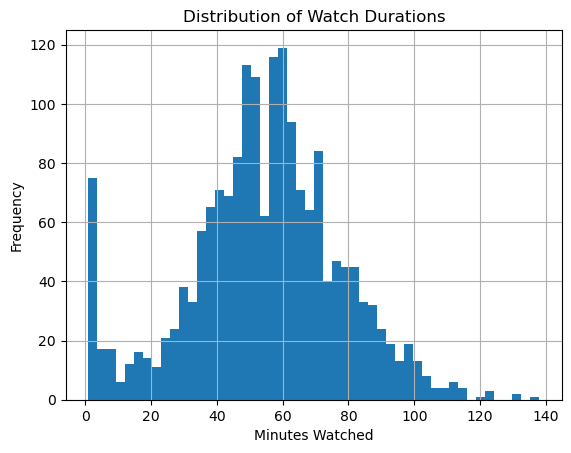

In [35]:
import matplotlib.pyplot as plt

watches["minutes_watched"].hist(bins=50)
plt.xlabel("Minutes Watched")
plt.ylabel("Frequency")
plt.title("Distribution of Watch Durations")
plt.show()

In [36]:
interaction_counts = watches.groupby("user_id")["movie_id"].count()
print("Avg movies per user:", interaction_counts.mean())
print("Max movies by a user:", interaction_counts.max())

movie_counts = watches.groupby("movie_id")["user_id"].count()
print("Avg users per movie:", movie_counts.mean())
print("Max users for a movie:", movie_counts.max())

Avg movies per user: 6.374125874125874
Max movies by a user: 20
Avg users per movie: 1.6989748369058715
Max users for a movie: 13


In [37]:
import requests
import pandas as pd
import os

BASE_URL = "http://128.2.220.241:8080"
os.makedirs("data/meta", exist_ok=True)

In [ ]:
def fetch_movie(movie_id):
    url = f"{BASE_URL}/movie/{movie_id}"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            data["movie_id"] = movie_id  
            return data
    except Exception as e:
        print(f"Error fetching {movie_id}: {e}")
    return None

# get unique movie_ids from watches & ratings
movie_ids = set(watches["movie_id"].unique()) | set(ratings_df["movie_id"].unique())

movies_data = [fetch_movie(mid) for mid in movie_ids]
movies_df = pd.DataFrame([m for m in movies_data if m])

movies_df.to_parquet("data/meta/movies.parquet", index=False)
print("Saved movies.parquet with shape:", movies_df.shape)

✅ Saved movies.parquet with shape: (1075, 24)


In [ ]:
def fetch_user(user_id):
    url = f"{BASE_URL}/user/{user_id}"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            return resp.json()
    except Exception as e:
        print(f"Error fetching {user_id}: {e}")
    return None

# get unique users from watches & ratings
user_ids = set(watches["user_id"].unique()) | set(ratings_df["user_id"].unique())

users_data = [fetch_user(uid) for uid in user_ids]
users_df = pd.DataFrame([u for u in users_data if u])

users_df.to_parquet("data/meta/users.parquet", index=False)
print("Saved users.parquet with shape:", users_df.shape)

✅ Saved users.parquet with shape: (287, 4)


In [40]:
print(movies_df.head(2))
print(users_df.head(2))

                           id  tmdb_id    imdb_id                  title  \
0  the+boy+who+could+fly+1986    24086  tt0090768  The Boy Who Could Fly   
1                memento+2000       77  tt0209144                Memento   

          original_title  adult belongs_to_collection   budget  \
0  The Boy Who Could Fly  False                    {}        0   
1                Memento  False                    {}  9000000   

                                              genres                 homepage  \
0  [{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...                     null   
1  [{'id': 9648, 'name': 'Mystery'}, {'id': 53, '...  http://www.otnemem.com/   

   ...                               production_companies  \
0  ...  [{'name': 'Lorimar Motion Pictures', 'id': 1887}]   
1  ...  [{'name': 'Summit Entertainment', 'id': 491}, ...   

                                production_countries release_date   revenue  \
0                                                 []   1986-08-15